In [39]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
%pip install torchinfo
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.


In [40]:
from pathlib import Path

DATA_DIR = Path.home() / "datasets" # ~/datasets/에 데이터셋 파일 저장 

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=32,
    shuffle=False
)

# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Files already downloaded and verified
Files already downloaded and verified
Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10
Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


In [41]:
# 정규화
transform = transforms.Compose([
    transforms.ToTensor()  # uint8 → float32 변환 + 0~1 정규화
])

10
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


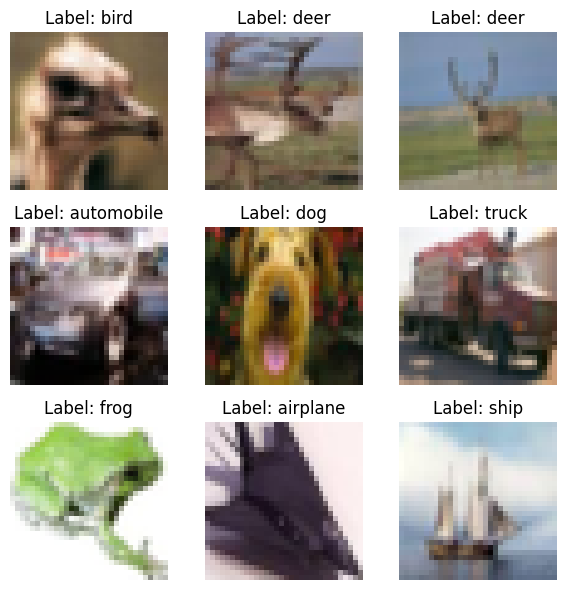

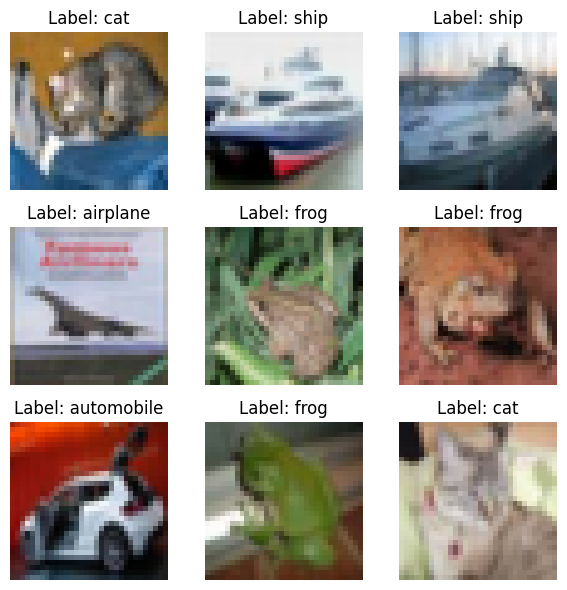

In [42]:
num_classes = len(trainset.classes)
class_names = trainset.classes

print(num_classes)
print(class_names)

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    
# 학습 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(trainloader)
# 테스트 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(testloader)

In [43]:
BATCH_SIZE = 256
EPOCH = 15

# CIFAR-10 데이터셋에 대해 Normalize와 Tensor 변환을 적용하는 코드
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 Tensor로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # VGG-16 표준 정규화
])

trainset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


---
### ResNet - Project



---

In [44]:
import torch
import torch.nn as nn

In [45]:
def conv3x3(in_channels, out_channels, stride=1): # padding 적용된 3x3 Conv Layer
  
    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False
    )

In [46]:
def conv1x1(in_channels, out_channels, stride=1): # padding 적용된 1x1 Conv Layer, ResNet-50 병목구조용

    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=1,
        stride=stride,
        padding=0,
        bias=False
    )

기본 Residual Block 구현

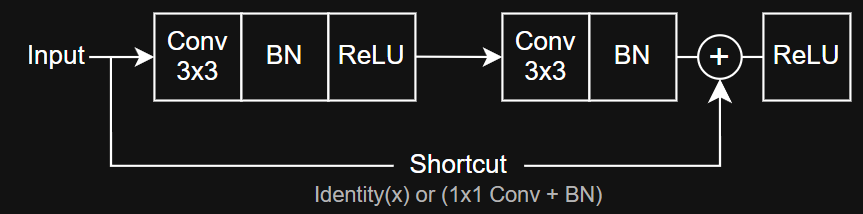

In [47]:
class BasicBlock(nn.Module):
    expansion = 1 # 출력 채널 수 = out_channels * expansion / 병목구조에선 4 

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # 첫 번째 3x3 conv
        # stage가 바뀔 때(conv2_x -> conv3_x 같은 때)는 여기서 stride=2를 사용해서 feature map 크기를 줄임
        self.conv1 = conv3x3(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=stride
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # 두 번째 3x3 conv
        # 두 번째 conv는 공간 크기를 더 줄이지 않으므로 stride=1
        self.conv2 = conv3x3(
            in_channels=out_channels,
            out_channels=out_channels,
            stride=1
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # shortcut 경로
        # 입력과 출력의 shape이 다르면 1x1 conv로 맞춰줌
        self.downsample = None 

#           크기가 달라졌거나 / 채널 수가 달라지거나 -> shape 맞춰야함(1x1 Conv & BatchNorm)
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                conv1x1(
                    in_channels=in_channels,
                    out_channels=out_channels * self.expansion,
                    stride=stride
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        # main path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # shortcut path
        if self.downsample is not None:
            identity = self.downsample(x)

        # residual addition
        out = out + identity
        out = self.relu(out)

        return out

In [48]:
class PlainBasicBlock(nn.Module): # residual connection 없는 plain block 구현
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = conv3x3(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=stride
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = conv3x3(
            in_channels=out_channels,
            out_channels=out_channels,
            stride=1
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        return out

Bottleneck block 구현

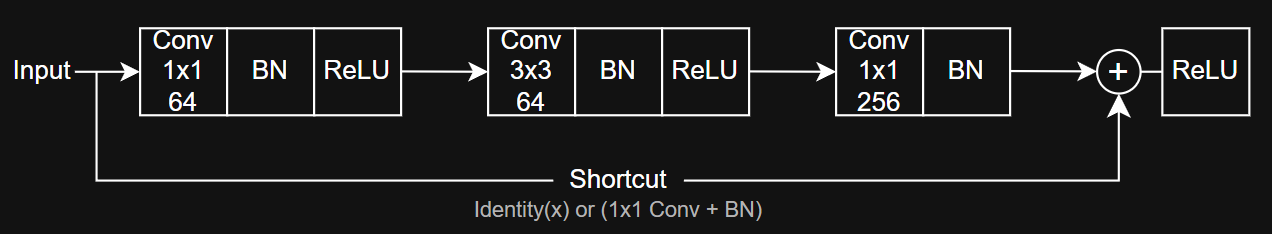

In [49]:
class BottleneckBlock(nn.Module):
    expansion = 4 # 1x1로 줄였으니까 마지막에 64*4로 늘려줘야함 

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # 1x1 conv -> 채널 수 감소 
        
        self.conv1 = conv1x1(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=1
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 3x3 conv: 특징 추출 
        self.conv2 = conv3x3(
            in_channels=out_channels,
            out_channels=out_channels,
            stride=stride
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 1x1 conv: 채널 수를 4배로 확장
        self.conv3 = conv1x1(
            in_channels=out_channels,
            out_channels=out_channels * self.expansion,
            stride=1
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        # shortcut 경로
        self.downsample = None

        # main path 출력과 shortcut의 shape이 다르면 1x1 conv로 맞춤
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                conv1x1(
                    in_channels=in_channels,
                    out_channels=out_channels * self.expansion,
                    stride=stride
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        # main path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out) # 같은 conv1을 쓰면 안되는 이유는 expansion 
        out = self.bn3(out)

        # shortcut path
        if self.downsample is not None:
            identity = self.downsample(x)

        # residual addition
        out = out + identity
        out = self.relu(out)

        return out

ResNet-50 full pre-activation용 bottleneck block 구현

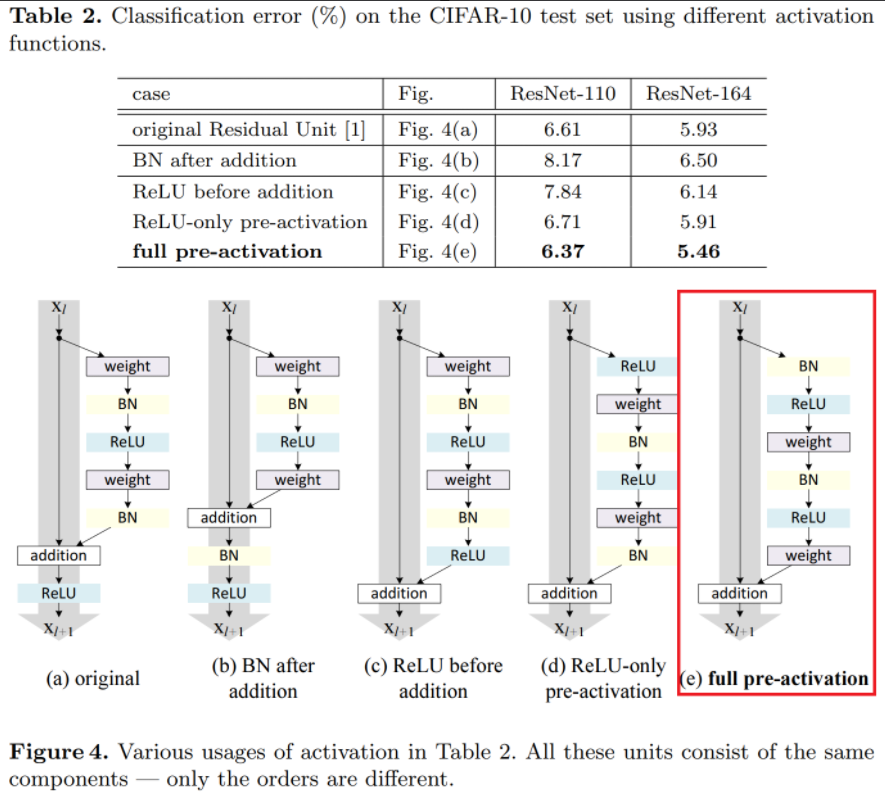

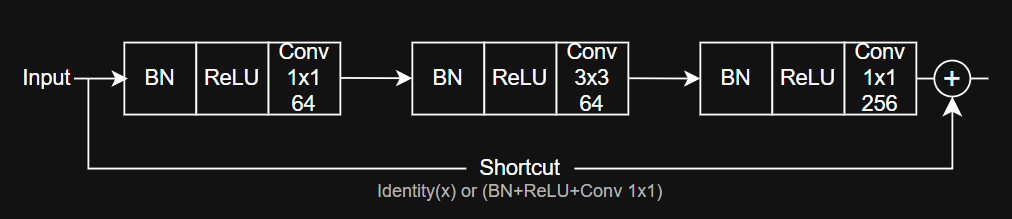


In [50]:
class PreActBottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # 첫 번째 pre-activation
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)

        # main branch
        self.conv1 = conv1x1(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=1
        )

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = conv3x3(
            in_channels=out_channels,
            out_channels=out_channels,
            stride=stride
        )

        self.bn3 = nn.BatchNorm2d(out_channels)
        self.conv3 = conv1x1(
            in_channels=out_channels,
            out_channels=out_channels * self.expansion,
            stride=1
        )

        # shortcut branch
        # shape이 다를 때만 projection shortcut 사용
        self.downsample = None

        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = conv1x1(
                in_channels=in_channels,
                out_channels=out_channels * self.expansion,
                stride=stride
            )

    def forward(self, x):
        identity = x

        # pre-activation: x → BN → ReLU
        preact = self.bn1(x)
        preact = self.relu(preact)

        # shortcut 처리
        # shape이 다르면 BN-ReLU를 거친 preact에 1x1 conv 적용
        if self.downsample is not None:
            identity = self.downsample(preact)

        # main branch
        out = self.conv1(preact)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)

        # full pre-activation에서는 Add 뒤에 ReLU 없음
        out = out + identity

        return out

In [51]:
class PlainBottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        mid_channels = out_channels
        final_channels = out_channels * self.expansion

        self.conv1 = nn.Conv2d(
            in_channels,
            mid_channels,
            kernel_size=1,
            stride=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(mid_channels)

        self.conv2 = nn.Conv2d(
            mid_channels,
            mid_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(mid_channels)

        self.conv3 = nn.Conv2d(
            mid_channels,
            final_channels,
            kernel_size=1,
            stride=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(final_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # PlainNet이므로 residual connection 없음
        # out += identity 하지 않음

        out = self.relu(out)

        return out

ResNet 기본형(?) 구현

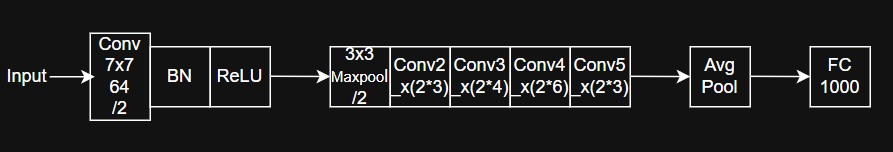

In [52]:
class ResNet(nn.Module):
    def __init__(
        self,
        block,
        layers,
        channels=[64, 128, 256, 512],
        num_classes=1000,
        preact=False
    ):
        super().__init__()

        self.in_channels = 64
        self.is_preact = block.__name__.lower().startswith("preact")

        # 첫번째 7x7 Conv
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        self.layer1 = self._make_layer(block, channels[0], layers[0], stride=1)
        self.layer2 = self._make_layer(block, channels[1], layers[1], stride=2)
        self.layer3 = self._make_layer(block, channels[2], layers[2], stride=2)
        self.layer4 = self._make_layer(block, channels[3], layers[3], stride=2)

        final_channels = channels[3] * block.expansion

        if self.is_preact:
            self.final_bn = nn.BatchNorm2d(final_channels)
            self.final_relu = nn.ReLU(inplace=True)
        else:
            self.final_bn = nn.Identity()
            self.final_relu = nn.Identity()

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(final_channels, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []

        layers.append(
            block(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride
            )
        )

        self.in_channels = out_channels * block.expansion

        for _ in range(1, num_blocks):
            layers.append(
                block(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.final_bn(x)
        x = self.final_relu(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

ResNet Config 


- ResNet 34 -> BasicBlock
- ResNet 34 Plain -> PlainBasicBlock
- ResNet 50 -> BottleneckBlock
- ResNet 50 Plain -> PlainBottleneckBlock
- ResNet 50-full-pre-activation -> PreActBottleneckBlock

In [53]:
RESNET_CONFIGS = {
    "plain34": {
        "block": PlainBasicBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
        "preact": False
    },

    "resnet34": {
        "block": BasicBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
        "preact": False
    },

    "plainnet50": {
        "block": PlainBottleneckBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
        "preact": False
    },

    "resnet50": {
        "block": BottleneckBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
        "preact": False
    },

    "resnet50_preact": {
        "block": PreActBottleneckBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
        "preact": True
    }
}

In [54]:
def build_resnet(model_name="resnet34", num_classes=1000):
    config = RESNET_CONFIGS[model_name]

    return ResNet(
        block=config["block"],
        layers=config["layers"],
        channels=config["channels"],
        num_classes=num_classes,
        preact=config["preact"]
    )

In [55]:
# resnet34 구조 확인
resnet_34 = build_resnet()
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

ㄴ ResNet-34 Summary : 예시와 일치함 

In [56]:
#resnet 50 구조 확인
resnet_50 = build_resnet("resnet50")
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─BottleneckBlock: 2-1              [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

ㄴ ResNet-50 Summary : 예시와 일치함 

---

### Ablation Study 
    - 1. ResNet-34 vs ResNet-34 plain - Residual Connection의 효과 검증 
    - 2. ResNet-50 vs ResNet-50 plain - Bottleneck 구조에서 Residual Connection의 효과 검증
    - 3. ResNet-50 vs ResNet-50-PreAct - BN/ReLU의 위치가 바뀐 Pre-Activation ResNet 성능 시험 
    
---

In [57]:
# Dataset Load - Oxford-IIIT Pet

from pathlib import Path

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet

import numpy as np
import matplotlib.pyplot as plt
import random

In [72]:
# 기본 설정

SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path.home() / "datasets"

BATCH_SIZE = 16
EPOCH = 15
IMG_SIZE = 224
NUM_CLASSES = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("DATA_DIR:", DATA_DIR)

Device: cuda
DATA_DIR: /home/thkim0/datasets


In [73]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [28]:
# Oxford-IIIT Pet Dataset 생성

trainset = OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",
    download=True,
    transform=train_transform
)

testset = OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="category",
    download=True,
    transform=test_transform
)

In [74]:
trainloader = DataLoader( #dataloader 생성 
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [75]:
# 데이터셋 기본 정보 확인

image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

print("Class examples:", trainset.classes[:10])

# Batch 확인

images, labels = next(iter(trainloader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label min:", labels.min().item())
print("Label max:", labels.max().item())
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10
Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))
Class examples: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Images shape: torch.Size([16, 3, 32, 32])
Labels shape: torch.Size([16])
Label min: 0
Label max: 9
Image dtype: torch.float32
Label dtype: torch.int64


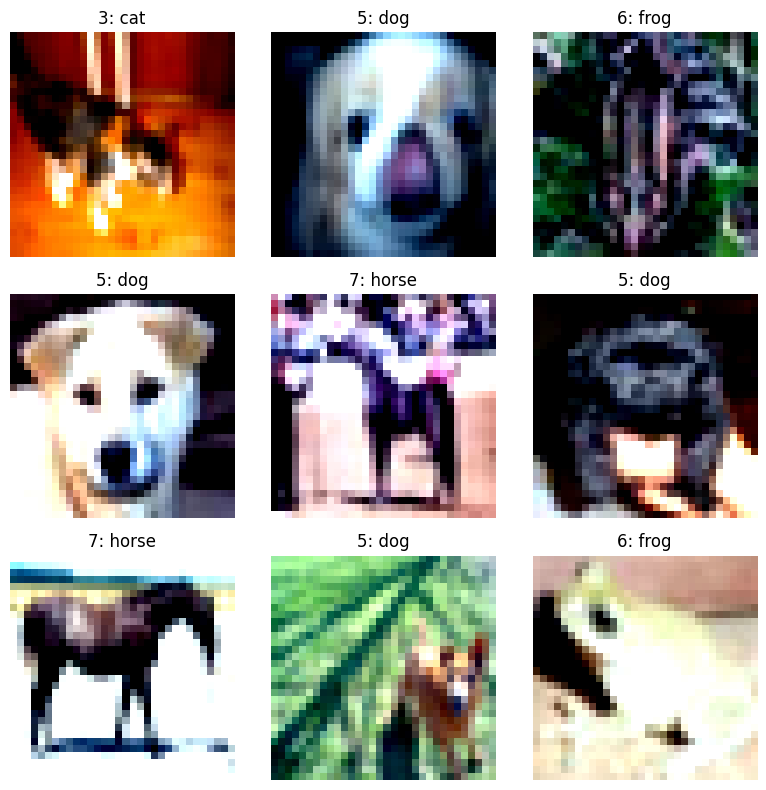

In [76]:
# 이미지 시각화

def imshow_pet(img):
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

    img = img.cpu() * std + mean
    img = torch.clamp(img, 0, 1)

    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))


def show_multiple_images(dataloader, n_images=9):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow_pet(images[i])

        label_idx = labels[i].item()
        label_name = trainset.classes[label_idx]

        ax.imshow(img)
        ax.set_title(f"{label_idx}: {label_name}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_multiple_images(trainloader)

In [77]:
EXPERIMENT_MODELS = {
    "Plain-34": "plain34",
    "ResNet-34": "resnet34",
    "Plain-50": "plainnet50",
    "ResNet-50": "resnet50",
    "ResNet-50-PreAct": "resnet50_preact",
}



In [85]:
# 모델 출력 확인 
def check_model_forward(model_name, config_name):
    model = build_resnet(config_name, num_classes=NUM_CLASSES).to(device)
    model.eval()

    images, labels = next(iter(trainloader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)

    print(f"{model_name}")
    print(f"  Config name: {config_name}")
    print(f"  Output shape: {outputs.shape}")
    print(f"  Expected shape: torch.Size([{images.size(0)}, {NUM_CLASSES}])")
    print()


for model_name, config_name in EXPERIMENT_MODELS.items():
    check_model_forward(model_name, config_name)

Plain-34
  Config name: plain34
  Output shape: torch.Size([16, 10])
  Expected shape: torch.Size([16, 10])

ResNet-34
  Config name: resnet34
  Output shape: torch.Size([16, 10])
  Expected shape: torch.Size([16, 10])

Plain-50
  Config name: plainnet50
  Output shape: torch.Size([16, 10])
  Expected shape: torch.Size([16, 10])

ResNet-50
  Config name: resnet50
  Output shape: torch.Size([16, 10])
  Expected shape: torch.Size([16, 10])

ResNet-50-PreAct
  Config name: resnet50_preact
  Output shape: torch.Size([16, 10])
  Expected shape: torch.Size([16, 10])



 Training Function

손실함수 : CE / 
optimizer : Adam


In [79]:
# 학습 함수 
import torch.optim as optim

def train_one_epoch(model, trainloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    return train_loss, train_acc

In [80]:
# 평가
def evaluate(model, testloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)

            running_loss += loss.item() * batch_size

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    return val_loss, val_acc

In [81]:
def fit_model(model, trainloader, testloader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            trainloader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = evaluate(
            model,
            testloader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return history

실험 대상 모델:

1. Plain-34
2. ResNet-34
3. Plain-50
4. ResNet-50
5. ResNet-50-PreAct

각 모델은 동일한 dataset,batch size,epoch,learning rate,optimizer 조건에서 학습한다.  
이를 통해 모델 구조 차이에 따른 validation accuracy와 validation loss 변화를 비교할 수 있다.

ResNet-50은 `Plain-50 vs ResNet-50` 비교와 `ResNet-50 vs ResNet-50-PreAct` 비교에 모두 사용되므로 한 번만 학습한 뒤 history를 재사용한다.

In [82]:
EPOCHS = 15
LR = 0.001

In [86]:
print("NUM_CLASSES:", NUM_CLASSES)
print("Train size:", len(trainset))
print("Test size:", len(testset))

images, labels = next(iter(testloader))
print("Image shape:", images.shape)
print("Label min/max:", labels.min().item(), labels.max().item())
with torch.no_grad():
    sample_outputs = model(images.to(device))

print("Model output shape:", sample_outputs.shape)

NUM_CLASSES: 10
Train size: 50000
Test size: 10000
Image shape: torch.Size([16, 3, 32, 32])
Label min/max: 0 9
Model output shape: torch.Size([16, 10])


In [87]:
histories = {}

for display_name, config_name in EXPERIMENT_MODELS.items():
    print("=" * 60)
    print(f"Training {display_name}")
    print(f"Config: {config_name}")
    print("=" * 60)

    torch.cuda.empty_cache()

    model = build_resnet(config_name, num_classes=NUM_CLASSES).to(device)

    history = fit_model(
        model=model,
        trainloader=trainloader,
        testloader=testloader,
        epochs=EPOCHS,
        lr=LR,
        device=device
    )

    histories[display_name] = history

    del model
    torch.cuda.empty_cache()

Training Plain-34
Config: plain34
Epoch [1/15] Train Loss: 1.9915 | Train Acc: 0.2188 | Val Loss: 1.9987 | Val Acc: 0.2184
Epoch [2/15] Train Loss: 1.9021 | Train Acc: 0.2620 | Val Loss: 1.8966 | Val Acc: 0.2704
Epoch [3/15] Train Loss: 1.8470 | Train Acc: 0.2913 | Val Loss: 1.7982 | Val Acc: 0.3195
Epoch [4/15] Train Loss: 1.8245 | Train Acc: 0.3023 | Val Loss: 1.7211 | Val Acc: 0.3412
Epoch [5/15] Train Loss: 1.7750 | Train Acc: 0.3267 | Val Loss: 1.9414 | Val Acc: 0.2711
Epoch [6/15] Train Loss: 1.9259 | Train Acc: 0.2536 | Val Loss: 2.0840 | Val Acc: 0.1993
Epoch [7/15] Train Loss: 2.0505 | Train Acc: 0.1934 | Val Loss: 2.1460 | Val Acc: 0.1791
Epoch [8/15] Train Loss: 2.0350 | Train Acc: 0.1992 | Val Loss: 1.9038 | Val Acc: 0.2609
Epoch [9/15] Train Loss: 2.0326 | Train Acc: 0.2045 | Val Loss: 2.0336 | Val Acc: 0.2005
Epoch [10/15] Train Loss: 2.0157 | Train Acc: 0.2218 | Val Loss: 2.0582 | Val Acc: 0.1999
Epoch [11/15] Train Loss: 1.9737 | Train Acc: 0.2263 | Val Loss: 2.0908 | V

In [88]:
histories.keys()

dict_keys(['Plain-34', 'ResNet-34', 'Plain-50', 'ResNet-50', 'ResNet-50-PreAct'])

--- 

### 결과 : Ablation Study Result

--- 

각 모델을 동일한 조건에서 학습하였다. 전체적인 validation accuracy는 높지 않았지만, 이는 pretrained weight 없이 모델을 처음부터 학습했고, Oxford-IIIT Pet 데이터셋의 학습 데이터 수가 깊은 ResNet 계열 모델을 충분히 학습시키기에는 많지 않기 때문으로 해석할 수 있다.

따라서 최종 정확도의 절대값보다는 모델 간 validation accuracy와 validation loss의 상대적인 차이를 중심으로 분석하였다.

    - 1. ResNet-34 vs ResNet-34 plain - Residual Connection의 효과 검증 

    

In [89]:
def plot_models_side_by_side(histories, model_names, title_prefix="Model Comparison"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Validation Accuracy
    ax = axes[0]

    for model_name in model_names:
        values = histories[model_name]["val_acc"]
        values = [v * 100 for v in values]
        epochs_range = range(1, len(values) + 1)

        ax.plot(
            epochs_range,
            values,
            marker="o",
            label=model_name
        )

    ax.set_title(f"{title_prefix} - Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy (%)")
    ax.legend()
    ax.grid(True)

    # 2. Validation Loss
    ax = axes[1]

    for model_name in model_names:
        values = histories[model_name]["val_loss"]
        epochs_range = range(1, len(values) + 1)

        ax.plot(
            epochs_range,
            values,
            marker="o",
            label=model_name
        )

    ax.set_title(f"{title_prefix} - Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

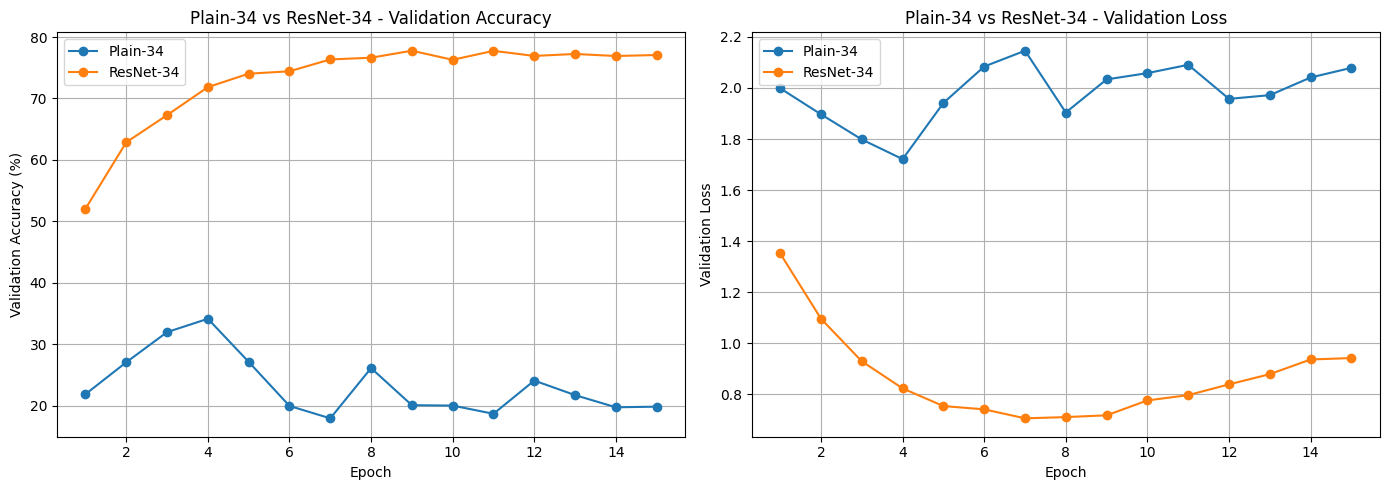

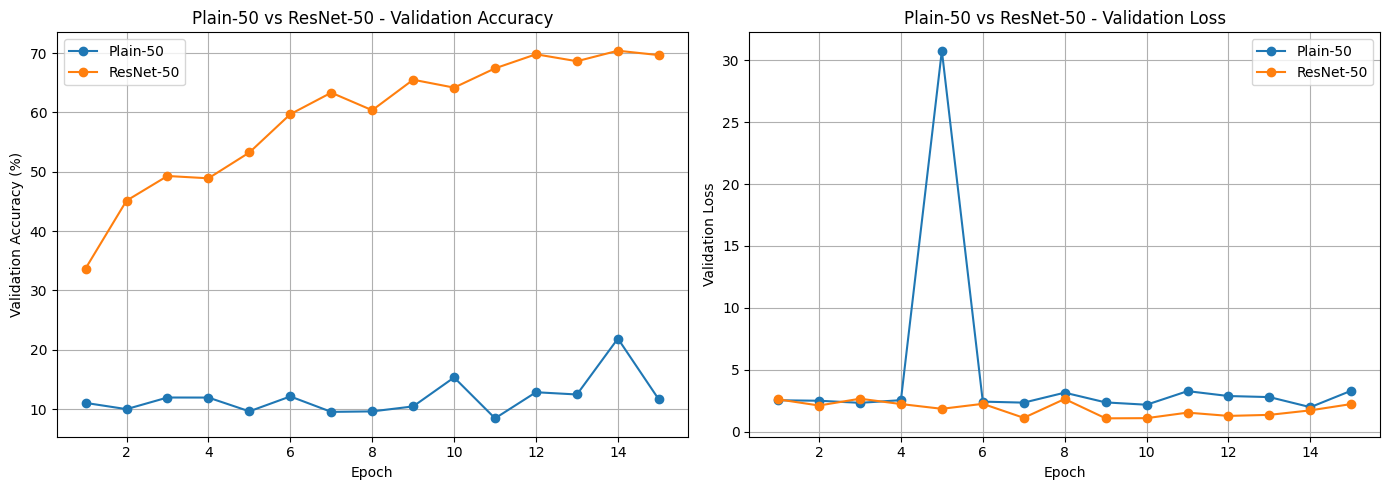

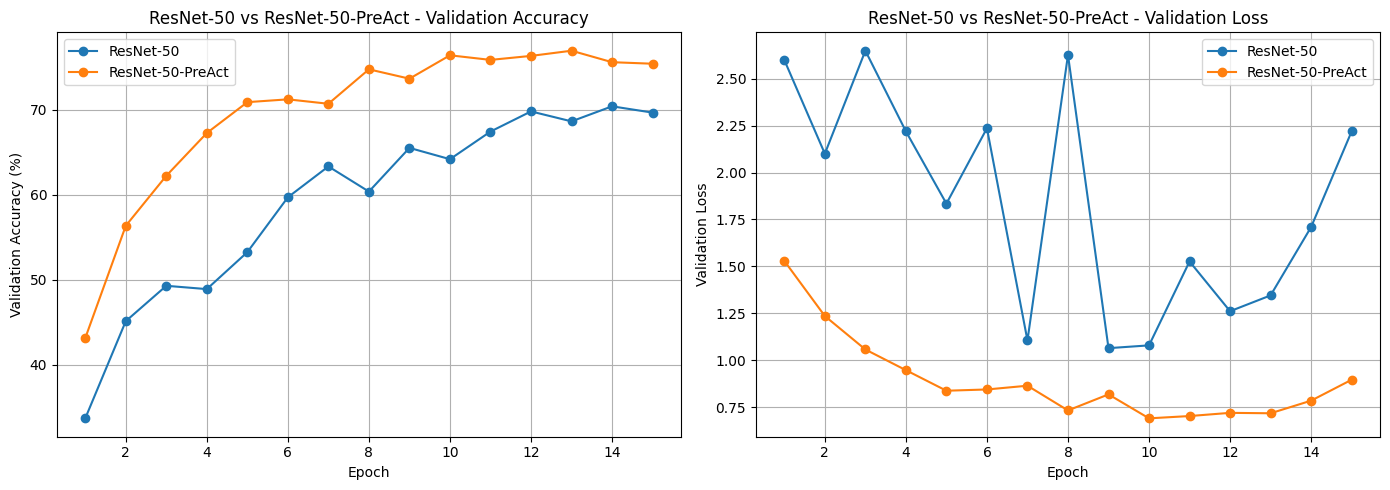

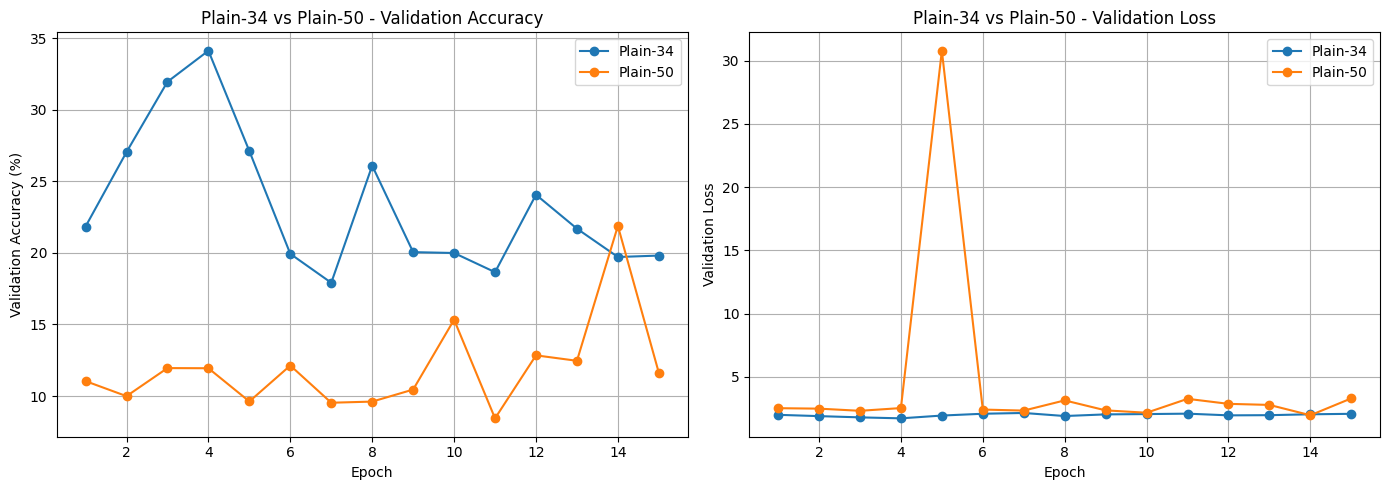

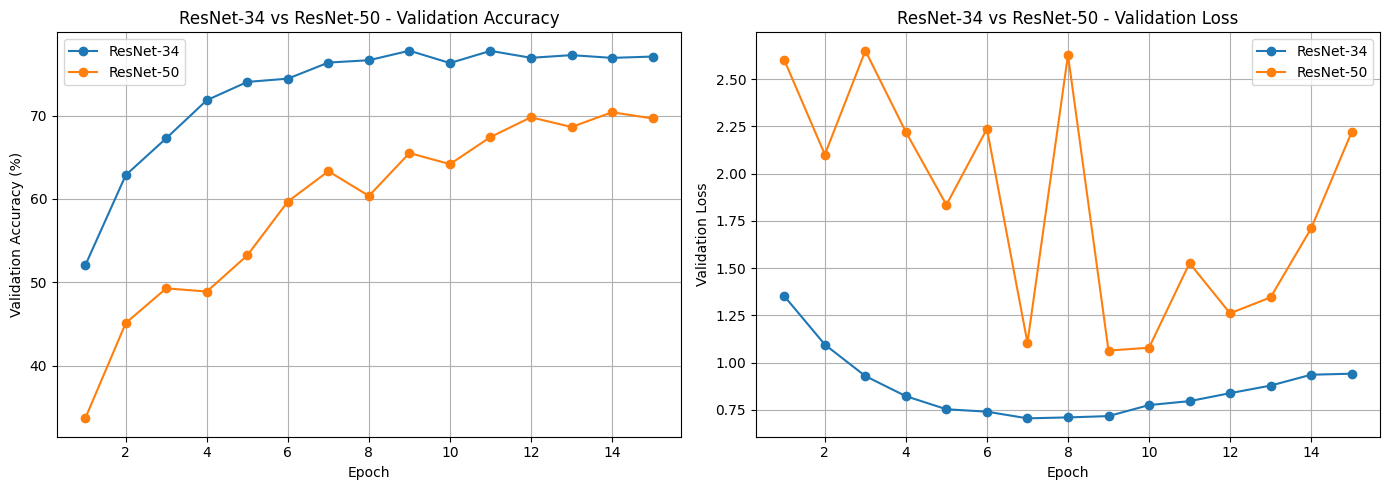

In [93]:
comparison_pairs = [
    ("Plain-34", "ResNet-34"),
    ("Plain-50", "ResNet-50"),
    ("ResNet-50", "ResNet-50-PreAct"),
    ("Plain-34", "Plain-50"),
    ("ResNet-34", "ResNet-50"),
]

for model_a, model_b in comparison_pairs:
    plot_models_side_by_side(
        histories,
        [model_a, model_b],
        title_prefix=f"{model_a} vs {model_b}"
    )

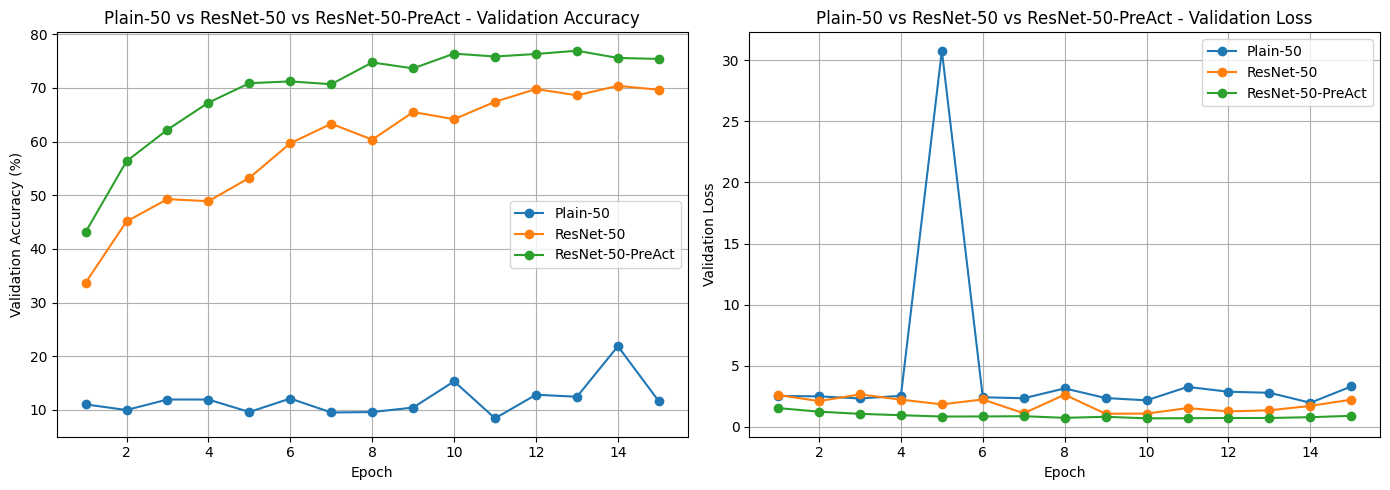

In [94]:
plot_models_side_by_side(
    histories,
    ["Plain-50", "ResNet-50", "ResNet-50-PreAct"],
    title_prefix="Plain-50 vs ResNet-50 vs ResNet-50-PreAct"
)

논문에서도 썼던 CIFAR-10 데이터세트를 기준으로 비교하면 차이가 더 극명하게 보인다. 


---

In [ ]:
MAX_EPOCHS = 100
PATIENCE = 10

In [ ]:
# ============================================================
# 번외 - CIFAR-10 데이터셋으로 ResNet-50 Full Pre-Activation 학습
# ============================================================

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torchinfo import summary

# ------------------------------------------------------------
# 1. CIFAR-10 Dataset Load
# ------------------------------------------------------------

DATA_DIR = Path.home() / "datasets"

NUM_CLASSES = 10
BATCH_SIZE = 128
MAX_EPOCHS = 100
PATIENCE = 10
LR = 0.001

# CIFAR-10 기준 mean/std
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std)
])

trainset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=train_transform
)

testset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=test_transform
)

trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("CIFAR-10 dataset loaded")
print(f"Train size: {len(trainset)}")
print(f"Test size: {len(testset)}")
print(f"Classes: {trainset.classes}")
print(f"NUM_CLASSES: {NUM_CLASSES}")


# ------------------------------------------------------------
# 2. ResNet-50 Full Pre-Activation Model 생성
# ------------------------------------------------------------

resnet50_preact_cifar = build_resnet(
    "resnet50_preact",
    num_classes=NUM_CLASSES
).to(device)

# CIFAR-10은 32x32 이미지이므로 ImageNet식 stem을 CIFAR용 stem으로 교체
# 기존: 7x7 conv, stride=2 + maxpool
# 변경: 3x3 conv, stride=1 + maxpool 제거

resnet50_preact_cifar.conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
).to(device)

resnet50_preact_cifar.maxpool = nn.Identity()

print("ResNet-50 Full Pre-Activation for CIFAR-10 created")

summary(
    resnet50_preact_cifar,
    input_size=(1, 3, 32, 32),
    device=device
)


# ------------------------------------------------------------
# 3. 모델 출력 확인
# ------------------------------------------------------------

images, labels = next(iter(trainloader))
images = images.to(device)

with torch.no_grad():
    outputs = resnet50_preact_cifar(images)

print("Input:", images.shape)
print("Output:", outputs.shape)
print("Expected:", torch.Size([images.size(0), NUM_CLASSES]))


# ------------------------------------------------------------
# 4. CIFAR-10 학습
# ------------------------------------------------------------

resnet50_preact_cifar, cifar10_preact_history = fit_model_with_early_stopping(
    model=resnet50_preact_cifar,
    trainloader=trainloader,
    testloader=testloader,
    max_epochs=MAX_EPOCHS,
    lr=LR,
    device=device,
    patience=PATIENCE,
    min_delta=0.001,
    save_path="best_resnet50_preact_cifar10.pth"
)

Files already downloaded and verified
Files already downloaded and verified
CIFAR-10 dataset loaded
Train size: 50000
Test size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES: 10
ResNet-50 Full Pre-Activation for CIFAR-10 created
Input: torch.Size([128, 3, 32, 32])
Output: torch.Size([128, 10])
Expected: torch.Size([128, 10])


NameError: name 'fit_model_with_early_stopping' is not defined